In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
def load_data(base_path):
    print("Loading Network data...")
    attack_1 = pd.read_csv(f'{base_path}/Network datatset/csv/attack_1.csv')
    attack_2 = pd.read_csv(f'{base_path}/Network datatset/csv/attack_2.csv')
    attack_3 = pd.read_csv(f'{base_path}/Network datatset/csv/attack_3.csv')
    normal = pd.read_csv(f'{base_path}/Network datatset/csv/normal.csv')

    attack_1.columns = normal.columns
    attack_2.columns = normal.columns
    attack_3.columns = normal.columns

    print("Loading Physical data...")
    phy_att_1 = pd.read_csv(f'{base_path}/Physical dataset/phy_att_1.csv', encoding="utf-16le", sep='\t')
    phy_att_2 = pd.read_csv(f'{base_path}/Physical dataset/phy_att_2.csv', encoding="utf-16le", sep='\t')
    phy_att_3 = pd.read_csv(f'{base_path}/Physical dataset/phy_att_3.csv', encoding="utf-16le", sep='\t')
    phy_norm = pd.read_csv(f'{base_path}/Physical dataset/phy_norm.csv', encoding="utf-16le", sep='\t')

    print("Merging data...")
    network_data = pd.concat([attack_1, attack_2, attack_3, normal], axis=0, ignore_index=True)
    physical_data = pd.concat([phy_att_1, phy_att_2, phy_att_3, phy_norm], axis=0, ignore_index=True)

    return network_data, physical_data

In [4]:
# Chargement des données
network_data, physical_data = load_data("dataset/")

Loading Network data...
Loading Physical data...
Merging data...


# Analyse des features réseau

In [4]:
network_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24306714 entries, 0 to 24306713
Data columns (total 16 columns):
 #   Column           Dtype  
---  ------           -----  
 0   Time             object 
 1   mac_s            object 
 2   mac_d            object 
 3   ip_s             object 
 4   ip_d             object 
 5   sport            float64
 6   dport            float64
 7   proto            object 
 8   flags            float64
 9   size             int64  
 10  modbus_fn        object 
 11  n_pkt_src        float64
 12  n_pkt_dst        float64
 13  modbus_response  object 
 14  label_n          int64  
 15  label            object 
dtypes: float64(5), int64(2), object(9)
memory usage: 2.9+ GB


In [5]:
network_data.isnull().sum()

Time                      0
mac_s                     0
mac_d                     0
ip_s                    940
ip_d                    940
sport               3452735
dport               3452735
proto                     0
flags               3452735
size                      0
modbus_fn           4046823
n_pkt_src               940
n_pkt_dst               940
modbus_response    14176421
label_n                   0
label                     0
dtype: int64

In [6]:
print("\nStatistiques descriptives:")
network_data.describe()


Statistiques descriptives:


,sport,dport,flags,size,n_pkt_src,n_pkt_dst,label_n
count,2.085398e+07,2.085398e+07,2.085398e+07,2.430671e+07,2.430577e+07,2.430577e+07,2.430671e+07
mean,2.994994e+04,2.981383e+04,1.092220e+04,2.365238e+02,3.975820e+01,3.956052e+01,2.755737e-01
std,2.948912e+04,2.951963e+04,1.342917e+04,4.674358e+02,2.806359e+01,2.782389e+01,4.468029e-01
min,2.500000e+01,2.500000e+01,0.000000e+00,6.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.020000e+02,5.020000e+02,1.100000e+04,6.500000e+01,1.500000e+01,1.500000e+01,0.000000e+00
50%,3.401900e+04,5.020000e+02,1.100000e+04,6.600000e+01,4.500000e+01,4.400000e+01,0.000000e+00
75%,6.131700e+04,6.131700e+04,1.100000e+04,6.600000e+01,5.000000e+01,5.000000e+01,1.000000e+00
max,6.164600e+04,6.164600e+04,1.100001e+07,1.514000e+03,1.000000e+02,1.000000e+02,1.000000e+00


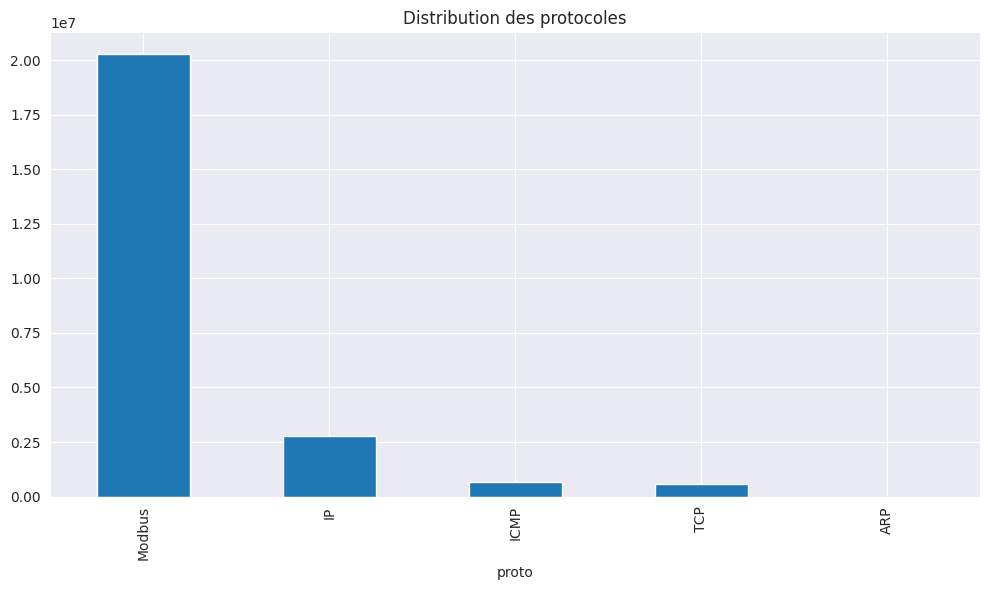

In [7]:
# Distribution des protocoles
plt.figure(figsize=(10, 6))
network_data['proto'].value_counts().plot(kind='bar')
plt.title('Distribution des protocoles')
plt.tight_layout()
plt.show()

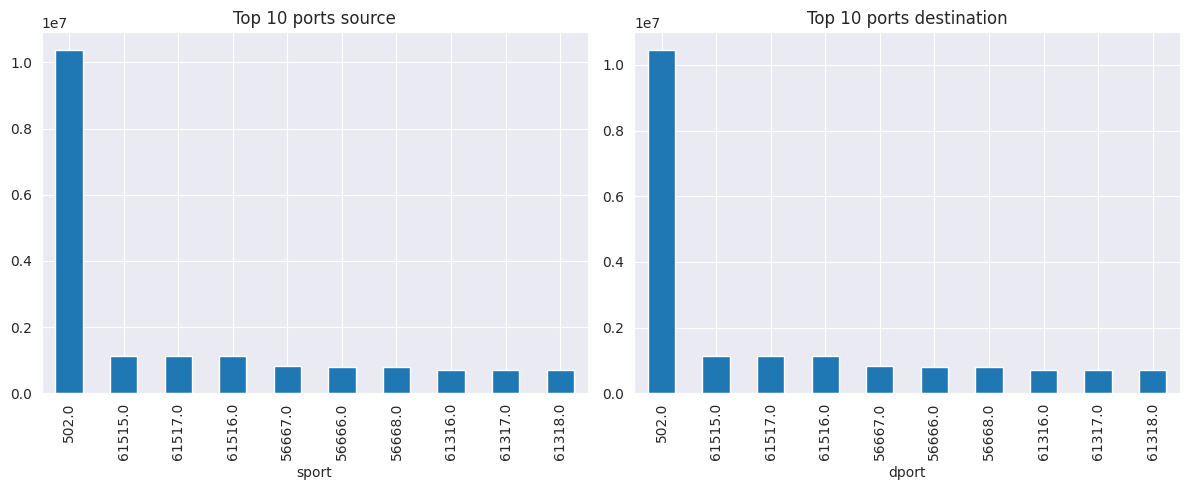

In [8]:
# Distribution des ports source/destination
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
network_data['sport'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 ports source')
plt.subplot(1, 2, 2)
network_data['dport'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 ports destination')
plt.tight_layout()
plt.show()

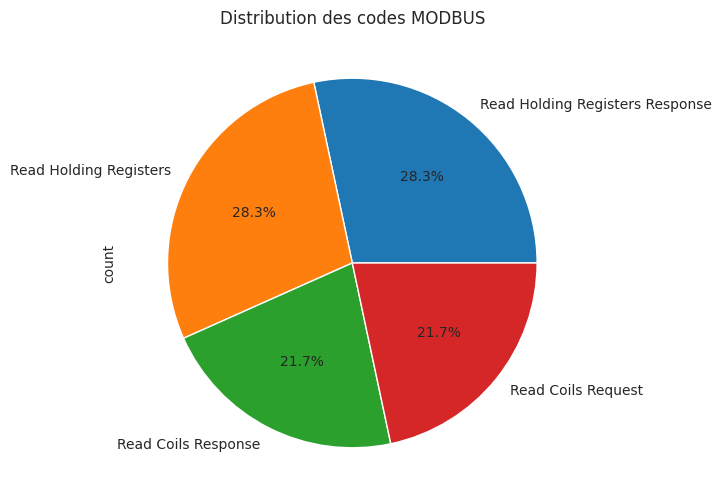

In [9]:
# Analyse des codes MODBUS
plt.figure(figsize=(8, 6))
network_data['modbus_fn'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribution des codes MODBUS')
plt.show()

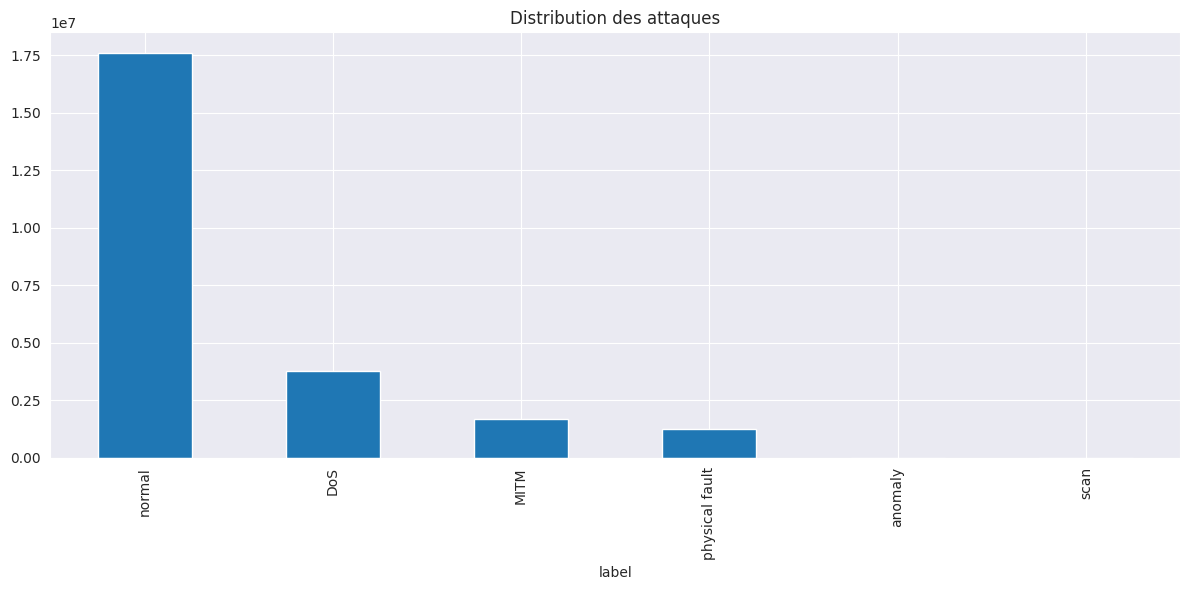

In [10]:
# Distribution des types d'attaques
plt.figure(figsize=(12, 6))
network_data['label'].value_counts().plot(kind='bar')
plt.title('Distribution des attaques')
plt.tight_layout()
plt.show()

# Analyse des features physiques:

In [11]:
physical_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9206 entries, 0 to 3427
Data columns (total 44 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Time           9206 non-null   object 
 1   Tank_1         9206 non-null   int64  
 2   Tank_2         9206 non-null   int64  
 3   Tank_3         9206 non-null   int64  
 4   Tank_4         9206 non-null   int64  
 5   Tank_5         9206 non-null   int64  
 6   Tank_6         9206 non-null   int64  
 7   Tank_7         9206 non-null   int64  
 8   Tank_8         9206 non-null   int64  
 9   Pump_1         9206 non-null   bool   
 10  Pump_2         9206 non-null   bool   
 11  Pump_3         9206 non-null   bool   
 12  Pump_4         9206 non-null   bool   
 13  Pump_5         9206 non-null   bool   
 14  Pump_6         9206 non-null   bool   
 15  Flow_sensor_1  9206 non-null   int64  
 16  Flow_sensor_2  9206 non-null   int64  
 17  Flow_sensor_3  9206 non-null   int64  
 18  Flow_sensor_4

In [11]:
physical_data.isnull().sum()

Time                0
Tank_1              0
Tank_2              0
Tank_3              0
Tank_4              0
Tank_5              0
Tank_6              0
Tank_7              0
Tank_8              0
Pump_1              0
Pump_2              0
Pump_3              0
Pump_4              0
Pump_5              0
Pump_6              0
Flow_sensor_1       0
Flow_sensor_2       0
Flow_sensor_3       0
Flow_sensor_4       0
Valv_1              0
Valv_2              0
Valv_3              0
Valv_4              0
Valv_5              0
Valv_6              0
Valv_7              0
Valv_8              0
Valv_9              0
Valv_10             0
Valv_11             0
Valv_12             0
Valv_13             0
Valv_14             0
Valv_15             0
Valv_16             0
Valv_17             0
Valv_18             0
Valv_19             0
Valv_20             0
Valv_21             0
Valv_22             0
Label_n          2104
Label               0
Lable_n          7102
dtype: int64

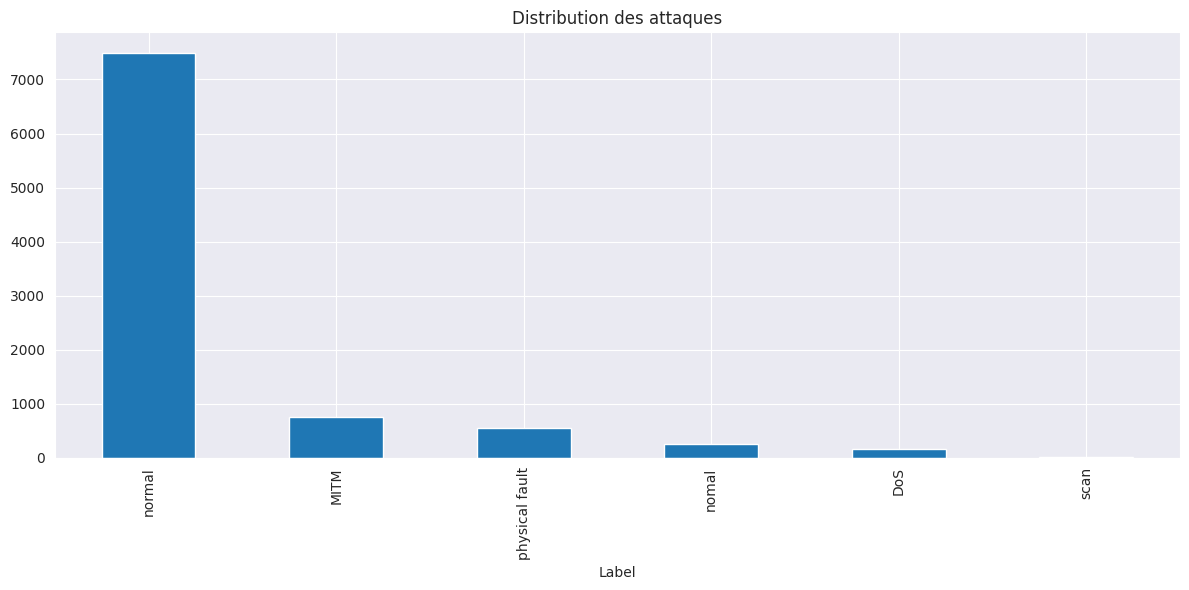

In [12]:
# Distribution des types d'attaques
plt.figure(figsize=(12, 6))
physical_data['Label'].value_counts().plot(kind='bar')
plt.title('Distribution des attaques')
plt.tight_layout()
plt.show()

In [13]:

# Statistiques descriptives des capteurs
sensors = [col for col in physical_data.columns if col.startswith('Ta')]
print("\nStatistiques des capteurs:")
physical_data[sensors].describe(include='all')


Statistiques des capteurs:


,Tank_1,Tank_2,Tank_3,Tank_4,Tank_5,Tank_6,Tank_7,Tank_8
count,9206.000000,9206.000000,9206.000000,9206.000000,9206.000000,9206.000000,9206.000000,9206.000000
mean,713.299044,927.126331,599.947100,282.917662,369.751792,196.465892,181.571367,170.329350
std,674.443296,692.773529,637.118395,351.902953,278.551885,174.515899,198.406152,183.080949
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.000000,104.250000,98.250000,20.000000,60.250000,1.000000,0.000000,0.000000
50%,613.000000,1001.000000,412.000000,33.000000,386.000000,181.000000,104.000000,91.000000
75%,1307.750000,1580.000000,960.750000,554.000000,610.000000,375.750000,369.000000,361.000000
max,2021.000000,2012.000000,3427.000000,1143.000000,838.000000,800.000000,812.000000,507.000000


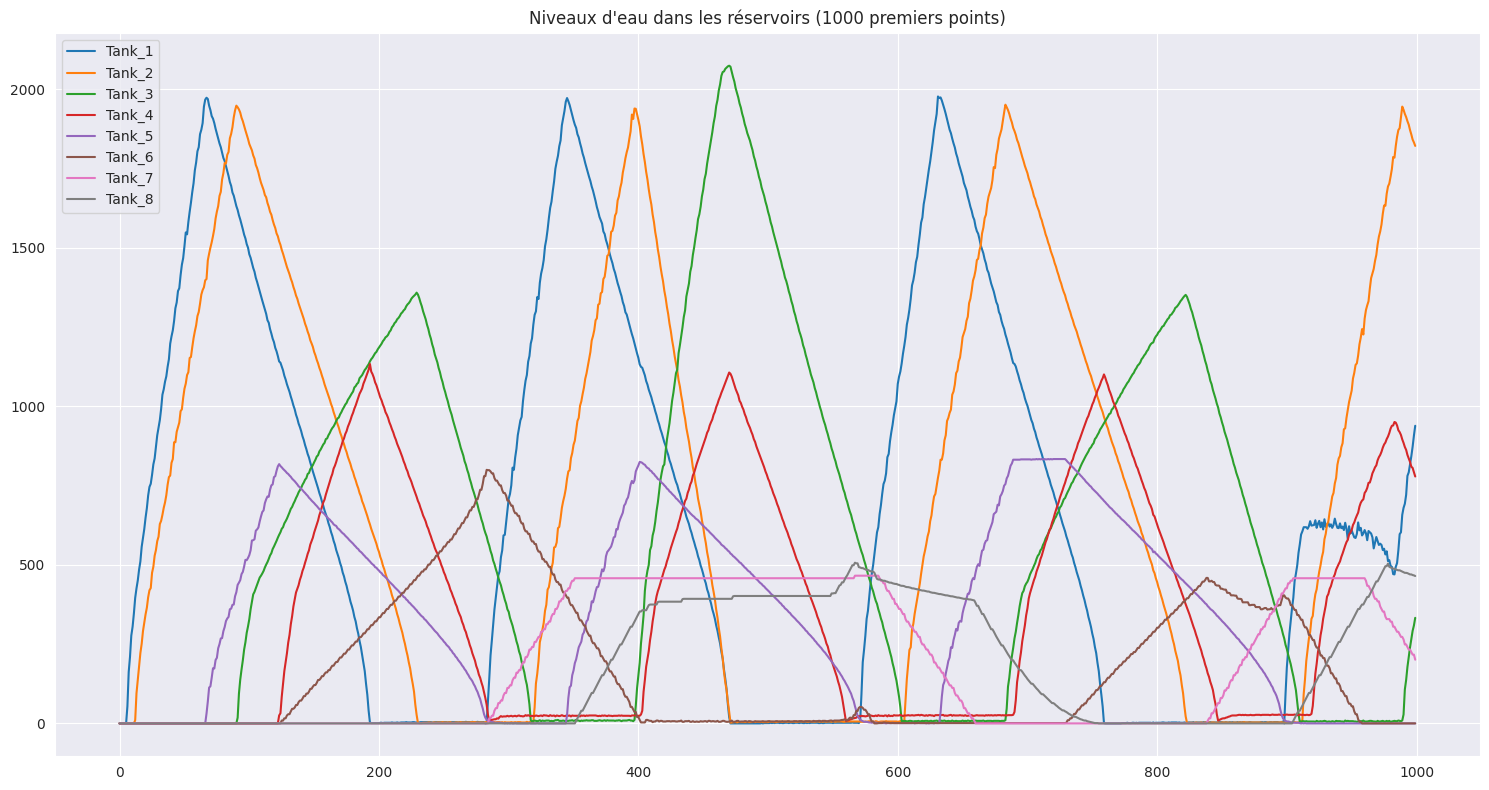

In [14]:
# Visualisation des niveaux d'eau pour chaque réservoir
plt.figure(figsize=(15, 8))
for sensor in sensors:
    plt.plot(physical_data[sensor].head(1000), label=sensor)
plt.title('Niveaux d\'eau dans les réservoirs (1000 premiers points)')
plt.legend()
plt.tight_layout()
plt.show()

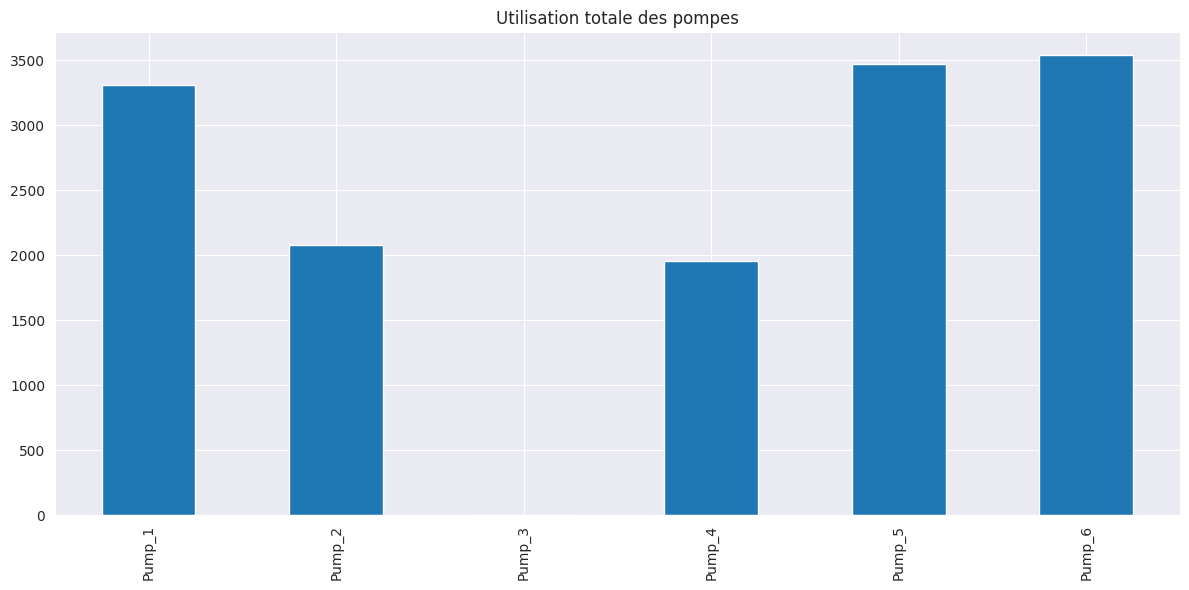

In [15]:

# État des pompes
pumps = [col for col in physical_data.columns if col.startswith('P')]
plt.figure(figsize=(12, 6))
physical_data[pumps].sum().plot(kind='bar')
plt.title('Utilisation totale des pompes')
plt.tight_layout()
plt.show()

# Analyse combinée

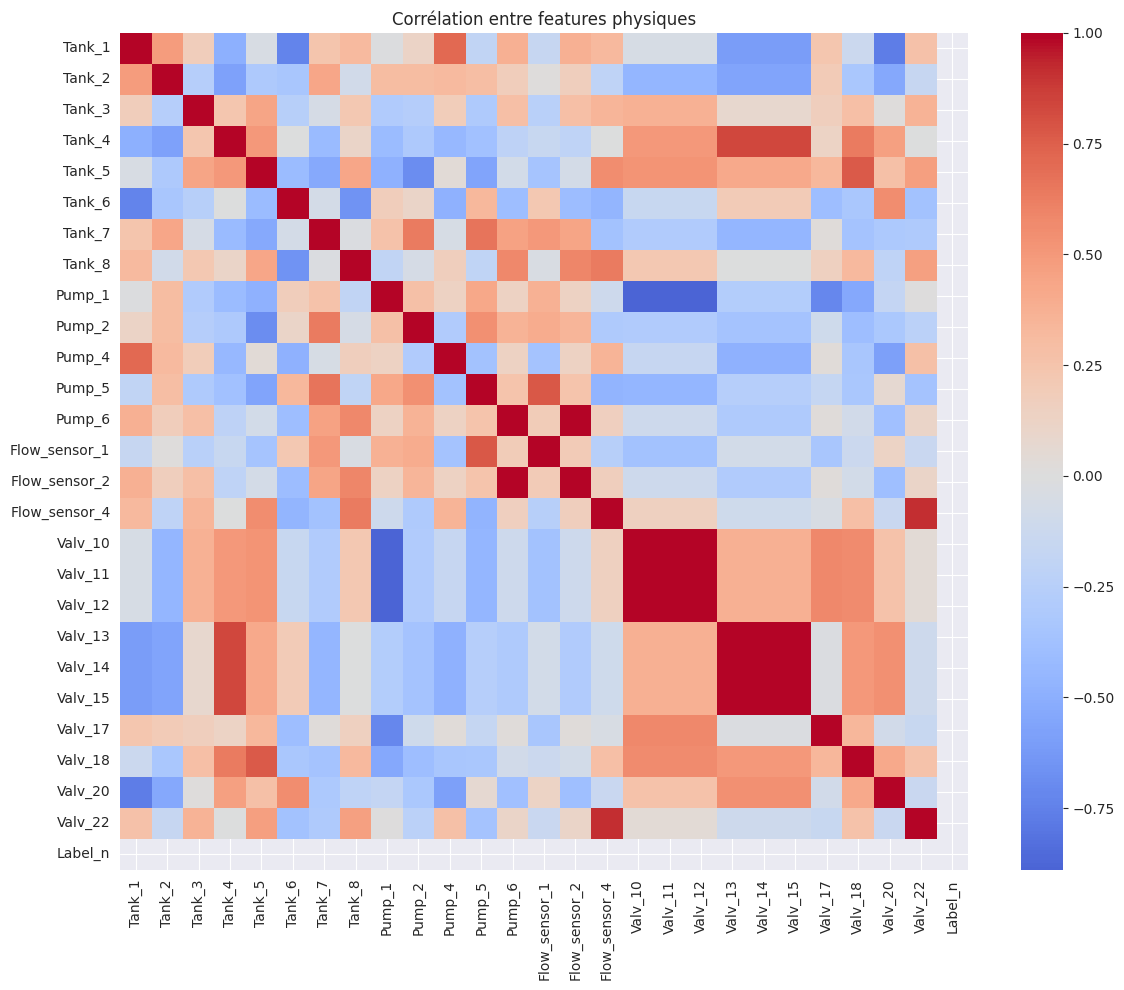

In [38]:
dataForCorr = physical_data[physical_data["Label"] != "normal"]
dataForCorr = dataForCorr.loc[:, (dataForCorr != False).any(axis=0)]
attack_corr = dataForCorr.drop(columns=['Label', 'Time']).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(attack_corr, cmap='coolwarm', center=0)
plt.title('Corrélation entre features physiques')
plt.tight_layout()
plt.show()

# Cleaning

In [5]:
network_data["Time"] = pd.to_datetime(network_data["Time"], errors="coerce")
physical_data["Time"] = pd.to_datetime(physical_data["Time"], errors="coerce")

In [6]:
physical_data['Label_n'] = physical_data['Label_n'].combine_first(physical_data['Lable_n'])
physical_data = physical_data.drop(columns=['Lable_n'])

In [7]:
physical_data = physical_data.dropna(subset=['Time'])
network_data = network_data.dropna(subset=['Time'])

In [8]:
def parse_value(value):
    import ast
    if value == 'None':
        return None
    try:
        # Safely evaluate the string and extract the number
        return ast.literal_eval(value)[0]
    except (ValueError, IndexError, TypeError):
        return None


network_data['modbus_response'] = network_data['modbus_response'].apply(parse_value)

# IA

In [1]:
def get_one_hot_encoding(dataframe):
    if dataframe is None:
        return None
    return pd.get_dummies(dataframe)


def get_is_attacked_data(dataframe):
    res = get_one_hot_encoding(dataframe.drop(['Time', 'modbus_response', 'label'], axis=1))
    res['modbus_response'] = dataframe['modbus_response']
    res.loc[res['modbus_response'].notnull(), 'modbus_response'] = res.loc[res[
        'modbus_response'].notnull(), 'modbus_response'].str[1:-1].astype(int)
    return res

# Detection DDoS network

In [9]:
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

columns_to_use = ['sport', 'dport', 'flags', 'size', 'n_pkt_src', 'n_pkt_dst', 'label_n']
df = network_data[columns_to_use]

In [10]:
from sklearn.preprocessing import StandardScaler

X = df.drop('label_n', axis=1)
y = df['label_n']

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = IsolationForest(n_estimators=100, contamination=0.1, random_state=42)

In [11]:
X_train

array([[-0.9986036 ,  1.07390152,  0.00579335, -0.366946  , -0.88221767,
         0.33925844],
       [ 0.90599714, -0.99296062,  0.00579335, -0.36480667,  0.11551657,
        -0.91865364],
       [-0.9986036 ,  1.06716024,  0.00579335, -0.366946  , -0.9534844 ,
         0.15955671],
       ...,
       [ 1.07039675, -0.99296062,  0.00579335, -0.36480667,  0.36495013,
        -0.8827133 ],
       [ 0.95079332, -0.99296062,  0.00579335, -0.36480667,  0.32931676,
        -0.8827133 ],
       [ 1.07046457, -0.99296062,  0.00579335, -0.36480667,  0.36495013,
        -0.8827133 ]], shape=(19445354, 6))

In [12]:
y_train

16873100    0
2460657     0
6285162     0
23929122    0
829247      0
           ..
13315101    1
21081806    0
23327870    0
16094491    0
23200624    0
Name: label_n, Length: 19445354, dtype: int64

In [13]:
model.fit(X_train)

IsolationForest(contamination=0.1, random_state=42)

In [14]:
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

def map_labels(labels):
    return np.where(labels == 1, 0, 1)

train_anomalies = map_labels(train_predictions)
test_anomalies = map_labels(test_predictions)

# Evaluation
print("Confusion Matrix:")
print(confusion_matrix(y_test, test_anomalies))

print("Classification Report:")
print(classification_report(y_test, test_anomalies))

# Save anomaly scores
scores = model.decision_function(X_test)
df_results = pd.DataFrame({
    'Anomaly_Score': scores,
    'Prediction': test_anomalies
})

Confusion Matrix:
[[3413574  106733]
 [1075703  265329]]
Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.97      0.85   3520307
           1       0.71      0.20      0.31   1341032

    accuracy                           0.76   4861339
   macro avg       0.74      0.58      0.58   4861339
weighted avg       0.75      0.76      0.70   4861339



In [15]:
for i in range(25, 150, 25):
    model = IsolationForest(n_estimators=i, random_state=42)
    model.fit(X_train)
    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)

    def map_labels(labels):
        return np.where(labels == 1, 0, 1)  # 0: Normal, 1: Anomaly

    train_anomalies = map_labels(train_predictions)
    test_anomalies = map_labels(test_predictions)
    res = classification_report(y_test, test_anomalies, output_dict=True)
    print(f"Accuracy for {i} estimators is {res['accuracy']}")

Accuracy for 25 estimators is 0.8291246506363782
Accuracy for 50 estimators is 0.8327557489819163
Accuracy for 75 estimators is 0.8186664209181873
Accuracy for 100 estimators is 0.8168218673908567
Accuracy for 125 estimators is 0.8203747979723282


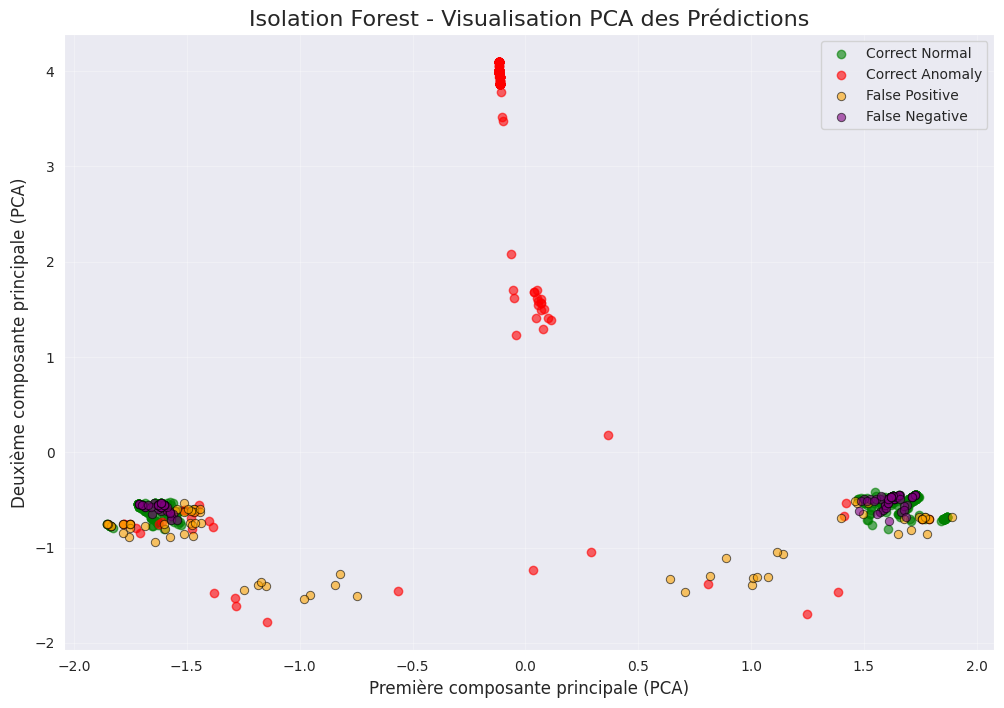

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Vérification et gestion des valeurs manquantes
X_test_clean = np.nan_to_num(X_test, nan=np.nanmean(X_test))

# Appliquer PCA sur les données X_test
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test_clean)

# Taille de l'échantillon pour la visualisation
sample_size = min(1000, X_test_pca.shape[0])
X_sample = X_test_pca[:sample_size]
y_true_sample = y_test[:sample_size].reset_index(drop=True)
y_pred_sample = test_anomalies[:sample_size]

# Création du scatter plot
plt.figure(figsize=(12, 8))

# Points normaux correctement prédits
normal_correct = (y_true_sample == 0) & (y_pred_sample == 0)
plt.scatter(
    X_sample[normal_correct, 0],
    X_sample[normal_correct, 1],
    c='green',
    label='Correct Normal',
    alpha=0.6
)

# Points anormaux correctement prédits
anomaly_correct = (y_true_sample == 1) & (y_pred_sample == 1)
plt.scatter(
    X_sample[anomaly_correct, 0],
    X_sample[anomaly_correct, 1],
    c='red',
    label='Correct Anomaly',
    alpha=0.6
)

# Points normaux mal classés comme anomalies
false_positive = (y_true_sample == 0) & (y_pred_sample == 1)
plt.scatter(
    X_sample[false_positive, 0],
    X_sample[false_positive, 1],
    c='orange',
    label='False Positive',
    edgecolors='black',
    linewidths=0.7,
    alpha=0.6
)

# Points anormaux mal classés comme normaux
false_negative = (y_true_sample == 1) & (y_pred_sample == 0)
plt.scatter(
    X_sample[false_negative, 0],
    X_sample[false_negative, 1],
    c='purple',
    label='False Negative',
    edgecolors='black',
    linewidths=0.7,
    alpha=0.6
)

# Ajouter les titres et légendes
plt.title("Isolation Forest - Visualisation PCA des Prédictions", fontsize=16)
plt.xlabel("Première composante principale (PCA)", fontsize=12)
plt.ylabel("Deuxième composante principale (PCA)", fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(alpha=0.3)
plt.show()


# KNN

In [40]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer


def get_one_hot_encoding(dataframe):
    if dataframe is None:
        return None
    return pd.get_dummies(dataframe)


def get_attack_label_data(dataframe, encoder):
    res = get_one_hot_encoding(dataframe.drop(['Time', 'modbus_response', 'label', 'label_n'], axis=1))
    #res['time'] = dataframe['Time']
    res['modbus_response'] = dataframe['modbus_response']
    imputer = SimpleImputer(strategy='most_frequent')
    X = imputer.fit_transform(res)
    y = encoder.fit_transform(dataframe['label'])
    return X, y

In [ ]:
network_encoder = LabelEncoder()
X, y = get_attack_label_data(network_data, network_encoder)

In [ ]:
print(np.unique(y))

In [ ]:
print(np.isnan(X).any())

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

knn = KNeighborsClassifier(n_neighbors=3)  # Choose the appropriate number of neighbors
knn.fit(X_train, y_train)

# SVM

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import datetime

In [44]:
scaler = StandardScaler()
svm_model = SVC(kernel='rbf', random_state=42)

In [61]:
def preprocess_data(df):
    df_processed = df.copy()

    df_processed['Time'] = pd.to_datetime(df_processed['Time'])
    df_processed['Hour'] = df_processed['Time'].dt.hour
    df_processed['Minute'] = df_processed['Time'].dt.minute
    df_processed['Second'] = df_processed['Time'].dt.second

    bool_columns = df_processed.select_dtypes(include=['bool']).columns
    for col in bool_columns:
        df_processed[col] = df_processed[col].astype(int)

    X = df_processed.drop(['Time', 'Label', 'Label_n'], axis=1)
    y = df_processed['Label']

    return X, y

In [62]:
def train_svm_model(X_train, y_train):
    scaler = StandardScaler()
    svm_model = SVC(kernel='rbf', random_state=42)

    X_train_scaled = scaler.fit_transform(X_train)

    svm_model.fit(X_train_scaled, y_train)

    return scaler, svm_model

In [84]:
def evaluate_model(scaler, model, X_test, y_test):
    X_test_scaled = scaler.transform(X_test)
    y_pred = model.predict(X_test_scaled)

    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)

    # Plot confusion matrix using heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=y_test.unique(), yticklabels=y_test.unique())
    plt.xlabel('Predicted labels')
    plt.ylabel('True labels')
    plt.title('Confusion Matrix')
    plt.show()

In [85]:
def detect_mitm_attacks(df, test_size=0.2):
    X, y = preprocess_data(df)

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    scaler, model = train_svm_model(X_train, y_train)

    print("Model Evaluation Results:")
    evaluate_model(scaler, model, X_test, y_test)

    return scaler, model

In [86]:
train_df = physical_data.copy()

Model Evaluation Results:
Classification Report:
                precision    recall  f1-score   support

           DoS       1.00      0.67      0.80        15
          MITM       0.90      0.95      0.92       130
        normal       0.98      0.98      0.98      1190
physical fault       0.95      0.93      0.94        86

      accuracy                           0.97      1421
     macro avg       0.96      0.88      0.91      1421
  weighted avg       0.98      0.97      0.97      1421


Confusion Matrix:


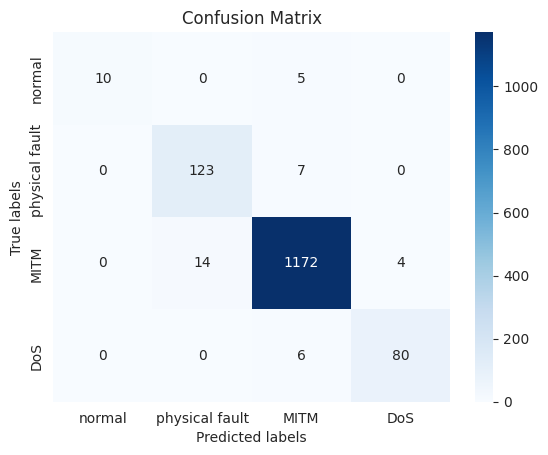

In [87]:
scaler, model = detect_mitm_attacks(train_df)